In [2]:
!pip install tensorflow_hub resampy
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import csv
import librosa
import matplotlib.pyplot as plt

# Load the YAMNet model from TensorFlow Hub
model = hub.load('https://tfhub.dev/google/yamnet/1')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.1 MB/s eta 0:00:00


In [3]:
# Find the class names
class_map_path = model.class_map_path().numpy()
with tf.io.gfile.GFile(class_map_path) as f:
  class_names = [line.split(',')[1] for line in f.read().splitlines()[1:]]

# Your "Safety Six" + Background filter indices
SAFETY_INDICES = {
    10: "Yell", 11: "Shouting", 12: "Screaming",
    14: "Crying", 437: "Crash", 441: "Glass", 442: "Shatter"
}
BACKGROUND_INDICES = [0, 66, 508, 494] # Speech, Chatter, TV, HVAC

In [4]:
def analyze_safety(audio_file):
    # Load audio and force 16kHz sample rate
    waveform, sr = librosa.load(audio_file, sr=16000)

    # Normalize the waveform to -1.0 to 1.0 range
    if np.max(np.abs(waveform)) > 0:
        waveform = waveform / np.max(np.abs(waveform))

    # Run the model
    scores, embeddings, spectrogram = model(waveform)

    # Use Max scores (Peak detection) instead of Mean scores
    peak_scores = np.max(scores, axis=0)

    print("--- Safety Analysis Results (Peak Detection) ---")
    detected_danger = False

    for idx, name in SAFETY_INDICES.items():
        score = peak_scores[idx]
        if score > 0.3:
            print(f"⚠️ ALERT: {name} detected (Peak Confidence: {int(score*100)}%)")
            detected_danger = True

    if not detected_danger:
        # Calculate safety confidence: 100% minus the highest danger score
        highest_danger = max([peak_scores[i] for i in SAFETY_INDICES.keys()])
        safety_conf = max(0, (1.0 - highest_danger) * 100)
        print(f"✅ Environment appears safe ({int(safety_conf)}% confidence).")

    return peak_scores

In [5]:
def smart_alert(peak_scores):
    # Get highest score from your Safety classes
    safety_score = max([peak_scores[i] for i in SAFETY_INDICES.keys()])

    # Revised "Demo-Ready" Logic with lowered thresholds for sensitivity
    if safety_score > 0.15:
        return f"🔴 RED ALERT: Dispatch Staff ({int(safety_score*100)}% Certainty)"
    elif safety_score > 0.10:
        return f"🟡 YELLOW WARNING: Monitor Area ({int(safety_score*100)}% Certainty)"
    else:
        # Express safety as the inverse of danger
        safety_conf = (1.0 - safety_score) * 100
        return f"🟢 GREEN: Normal Activity ({int(safety_conf)}% Confidence)"

In [6]:
def dynamic_vibe_check(audio_file):
    # Load and run model
    waveform, _ = librosa.load(audio_file, sr=16000)
    if np.max(np.abs(waveform)) > 0:
        waveform = waveform / np.max(np.abs(waveform))
    scores, _, _ = model(waveform)

    # Get the top 3 safety classes found in the clip
    safety_results = {SAFETY_INDICES[i]: np.max(scores[:, i]) for i in SAFETY_INDICES.keys()}
    sorted_results = sorted(safety_results.items(), key=lambda x: x[1], reverse=True)

    print("🔎 ENVIRONMENTAL SCAN:")
    for sound, confidence in sorted_results[:3]:
        if confidence > 0.05: # Lowered for demo sensitivity
            color = "🔴" if confidence > 0.3 else "🟡"
            print(f"{color} {sound}: {int(confidence*100)}% certainty")

    # The "Winner" logic for the Map
    top_sound, top_conf = sorted_results[0]
    if top_conf > 0.15:
        return f"ALARM: {top_sound} in progress."
    return "STATUS: Normal"

In [9]:
def plot_spectrogram(audio_file):
    waveform, _ = librosa.load(audio_file, sr=16000)
    _, _, spectrogram = model(waveform)

    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(spectrogram), aspect='auto', origin='lower')
    plt.title('Acoustic Signature (Privacy-Preserving View)')
    plt.ylabel('Frequency Bin')
    plt.xlabel('Time (Frames)')
    plt.colorbar(label='Log Mel-Energy')
    plt.show()

# Demo Audio Testing Code

In [10]:
from IPython.display import display, Javascript
from google.colab import output
import base64

RECORD_JS = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time));
const b2text = b => new Promise(resolve => {
  const reader = new FileReader();
  reader.onloadend = e => resolve(e.target.result);
  reader.readAsDataURL(b);
});

async function record(seconds) {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
  const recorder = new MediaRecorder(stream);
  const chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();
  await sleep(seconds * 1000);
  recorder.stop();
  return new Promise(resolve => {
    recorder.onstop = async () => {
      const blob = new Blob(chunks);
      const text = await b2text(blob);
      resolve(text);
    };
  });
}
"""

def record_audio(seconds=5, filename='test.wav'):
  display(Javascript(RECORD_JS))
  print(f"Recording for {seconds} seconds...")
  s = output.eval_js(f'record({seconds})')
  b = base64.b64decode(s.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(b)
  print(f"Saved to {filename}")

<IPython.core.display.Javascript object>

Recording for 5 seconds...
Saved to live_test.wav


/tmp/ipykernel_20415/625025395.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, _ = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


🔎 ENVIRONMENTAL SCAN:
🔴 Shouting: 35% certainty

VIBE CHECK: ALARM: Shouting in progress.


/tmp/ipykernel_20415/2709314157.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, sr = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


--- Safety Analysis Results (Peak Detection) ---
⚠️ ALERT: Shouting detected (Peak Confidence: 35%)

FINAL SYSTEM STATUS: 🔴 RED ALERT: Dispatch Staff (35% Certainty)


/tmp/ipykernel_20415/1545505567.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, _ = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


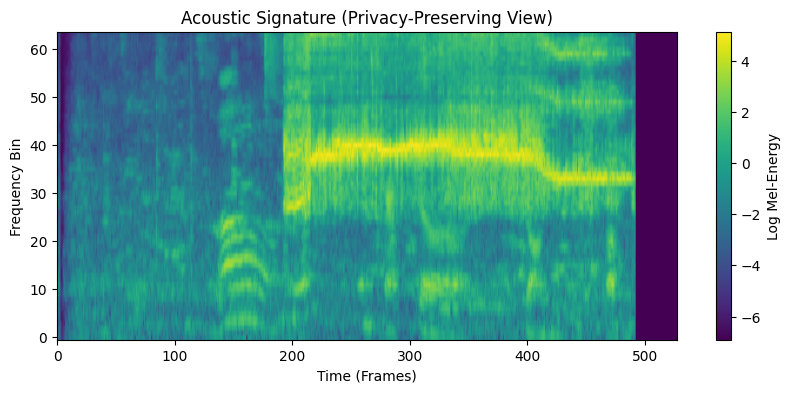

In [11]:
# 1. Record 5 seconds of "Live" shelter noise
record_audio(seconds=5, filename='live_test.wav')

# 2. Perform the Detailed Environmental Scan (Confidence Mapping)
vibe_status = dynamic_vibe_check('live_test.wav')
print(f"\nVIBE CHECK: {vibe_status}")

# 3. Analyze the file with your YAMNet logic
scores = analyze_safety('live_test.wav')

# 4. Run your Smart Alert Logic
status = smart_alert(scores)
print(f"\nFINAL SYSTEM STATUS: {status}")

# 5. Show the visual "Privacy" signature
plot_spectrogram('live_test.wav')

# Time-Stamp Logic Begins

### 📊 Proactive Trend Analysis: The "Vibe Heat-Map"
This section generates historical mock data to demonstrate how the system identifies systemic safety gaps (e.g., shift changes or unmonitored hours).

In [50]:
import pandas as pd
import datetime
import random
import seaborn as sns

# 1. Generate Mock Data for the last 7 days
def generate_mock_logs(days=7):
    locations = ['North Hallway', 'Laundry Room', 'Dining Area', 'Stairwell B']
    incident_types = list(SAFETY_INDICES.values())
    data = []

    start_date = datetime.datetime.now() - datetime.timedelta(days=days)

    for _ in range(150): # 150 simulated incidents
        delta = datetime.timedelta(days=random.randint(0, days),
                                   hours=random.randint(0, 23),
                                   minutes=random.randint(0, 59))
        timestamp = start_date + delta

        # Simulate a 'hot spot' during shift change (e.g., 7pm/19:00)
        if timestamp.hour == 19:
            location = 'North Hallway'
            itype = random.choice(['Yell', 'Shouting'])
        else:
            location = random.choice(locations)
            itype = random.choice(incident_types)

        data.append({
            'Timestamp': timestamp,
            'Hour': timestamp.hour,
            'Day': timestamp.strftime('%A'),
            'Location': location,
            'Type': itype,
            'Intensity': round(random.uniform(0.2, 0.9), 2)
        })

    return pd.DataFrame(data)

historical_df = generate_mock_logs()
display(historical_df.head())
print(f"Total Incidents Logged: {len(historical_df)}")

,Timestamp,Hour,Day,Location,Type,Intensity
0,2026-04-04 06:45:25.736506,6,Saturday,Dining Area,Shatter,0.52
1,2026-03-31 11:16:25.736506,11,Tuesday,Dining Area,Shatter,0.29
2,2026-04-01 14:10:25.736506,14,Wednesday,Stairwell B,Crash,0.79
3,2026-04-01 10:40:25.736506,10,Wednesday,Dining Area,Screaming,0.46
4,2026-04-04 01:29:25.736506,1,Saturday,Stairwell B,Crash,0.83


Total Incidents Logged: 150


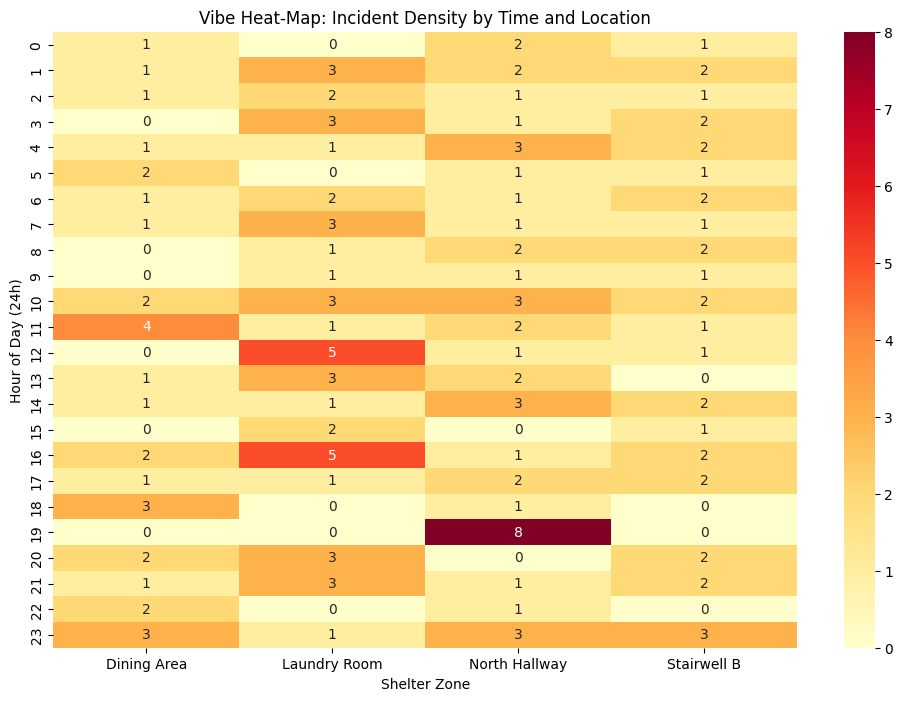

💡 STRATEGIC INSIGHT: Peak tension detected at 10:00. Recommended: Increase staff presence during this window.


In [51]:
def plot_vibe_heatmap(df):
    # Pivot data to see Hour vs Location incident counts
    heat_data = df.groupby(['Hour', 'Location']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 8))
    sns.heatmap(heat_data, annot=True, cmap='YlOrRd', fmt='d')
    plt.title('Vibe Heat-Map: Incident Density by Time and Location')
    plt.xlabel('Shelter Zone')
    plt.ylabel('Hour of Day (24h)')
    plt.show()

    # Insight calculation
    peak_hour = df['Hour'].value_counts().idxmax()
    print(f"💡 STRATEGIC INSIGHT: Peak tension detected at {peak_hour}:00. Recommended: Increase staff presence during this window.")

plot_vibe_heatmap(historical_df)